In [1]:
import torch
import torch.distributions as D
import gensn.distributions as G
import gensn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from task_transfer.routines import mc_marginal_log_likelihood

seed = 42
torch.manual_seed(seed)
rng = np.random.default_rng(seed)

ModuleNotFoundError: No module named 'task_transfer'

# Create observation dataset from ground truth joint distribution

In [2]:
# Pick 2d prior for visualization as of now
prior_dim = 2
conditional_dim = 2
mc_sample_size = (1,)
obs_batch_dim = 128
dataset_size = 10_000
train_size = 8_000
test_size = 2_000

In [3]:
# set true prior and conditional params
true_prior_mean = torch.rand((1, prior_dim))
true_prior_cov = torch.rand((prior_dim, prior_dim))
true_prior_cov = true_prior_cov @ true_prior_cov.T + torch.finfo(true_prior_cov.dtype).eps * torch.eye(prior_dim)
prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=true_prior_mean, covariance_matrix=true_prior_cov
)

likelihood_fn = torch.nn.Linear(prior_dim, conditional_dim)
likelihood_fn.weight.data = torch.rand(conditional_dim, prior_dim)
likelihood_fn.bias.data = torch.rand(conditional_dim)
conditional_cov = torch.rand((conditional_dim, conditional_dim))
conditional_cov = conditional_cov @ conditional_cov.T + torch.finfo(conditional_cov.dtype).eps * torch.eye(conditional_dim)
conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=conditional_cov
)
joint = G.Joint(prior=prior, conditional=conditional)

In [4]:
obs_samples, latent_samples = joint.sample((dataset_size,))
print(obs_samples.shape, latent_samples.shape)

torch.Size([10000, 1, 2]) torch.Size([10000, 1, 2])


In [24]:
# visualize the true prior
x, y = np.mgrid[-1.5:3:.01, -1.5:3:.01]
pos = np.dstack((x, y))
prior_pdf = prior(torch.tensor(pos)).exp()

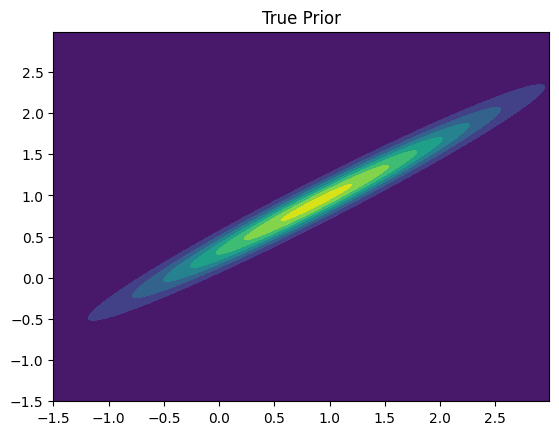

In [25]:
fig, ax = plt.subplots(dpi=100)
ax.contourf(x, y, prior_pdf)
ax.set_title("True Prior")
# ax.scatter(latent_samples[:, :, 0].flatten(), latent_samples[:,:, 1], s=1, c="r")
plt.show()

In [34]:
# create a pytorch dataloader with the observed samples
train_dataloader = DataLoader(
    TensorDataset(obs_samples[:train_size]),
    batch_size=obs_batch_dim,
    shuffle=True
)
test_dataloader = DataLoader(
    TensorDataset(obs_samples[train_size:]),
    batch_size=obs_batch_dim,
    shuffle=False
)

# Create a joint with a model prior and ground truth conditional

In [31]:
model_prior_mean = torch.nn.Parameter(torch.randn_like(true_prior_mean))
model_prior_cov = gensn.parameters.Covariance(n_dims=prior_dim)
model_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=model_prior_mean, covariance_matrix=model_prior_cov
)

model_likelihood_fn = likelihood_fn
model_conditional_cov = conditional_cov
model_conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=conditional_cov
)
joint = G.Joint(prior=model_prior, conditional=conditional)

In [36]:
obs = next(iter(train_dataloader))

In [ ]:
lr = 1e-3
optimizer = Adam(joint.prior.parameters(), lr=lr)
n_epochs = 100
for epoch in range(n_epochs):
    for obs_batch in train_dataloader:
        optimizer.zero_grad()
        obs_batch = obs_batch[0]
        loss = 
        loss = -joint.log_prob(obs_batch).mean()
        loss.backward()
        optimizer.step()